# 02 — Modelo Base: Regresión Logística
## Sistema de Alerta Temprana para Orientación Universitaria
### Pregunta D · TSDS 2025/2026 · Grupo 6

---

### Objetivo de este notebook

El modelo base cumple dos funciones en el proyecto. La primera es fijar una referencia cuantificada: cualquier modelo avanzado que construyamos en la Fase 3 debe superar estas métricas para justificar su complejidad adicional, y si no lo hace, el modelo más simple es el correcto. La segunda es extraer interpretabilidad estadística clásica — coeficientes, intervalos de confianza y odds ratios — que los modelos de boosting no proporcionan directamente.

La regresión logística es la elección natural para este punto de partida. Sus supuestos son más restrictivos que los de los árboles, pero sus coeficientes se traducen directamente en cambios en las log-odds de la clase objetivo. Para un orientador que necesita entender por qué el sistema ha levantado una alerta, esa transparencia tiene valor real.

---

### Estructura del notebook

1. Carga de los datos procesados del EDA
2. Diseño y justificación del pipeline de preprocesado
3. Modelo de referencia (dummy baseline)
4. Regresión logística con pipeline sklearn completo
5. Evaluación con métricas múltiples y análisis del umbral de decisión
6. Interpretación estadística con statsmodels: coeficientes, odds ratios e intervalos de confianza
7. Validación cruzada estratificada
8. Conclusiones y limitaciones del modelo base


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
from IPython.display import display

# Preprocesado y pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder, OrdinalEncoder, StandardScaler, TargetEncoder
)
from sklearn.impute import SimpleImputer

# Modelos y evaluación
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay,
    precision_recall_curve, roc_curve
)

# Interpretación estadística
import statsmodels.api as sm

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white',
                     'axes.titlesize': 13, 'axes.labelsize': 11})

COLOR_RIESGO  = '#E74C3C'
COLOR_EXITO   = '#27AE60'
COLOR_NEUTRAL = '#2C3E50'
COLOR_ACCENT  = '#F39C12'

print(f"scikit-learn {__import__('sklearn').__version__}  |  statsmodels {__import__('statsmodels').__version__}")


scikit-learn 1.6.1  |  statsmodels 0.14.4


---
## Sección 1. Carga de los Datos Procesados

Se cargan los cuatro archivos generados al final del notebook de EDA. El test set se carga en memoria pero no se usa para ninguna decisión de diseño — toda la estimación de rendimiento durante el desarrollo se hace sobre el train set mediante validación cruzada. El test set solo se toca en la evaluación final, una vez que el pipeline está completamente fijado.


In [2]:
# ── Rutas relativas al directorio del notebook ───────────────
base = '../data/processed/' if os.getcwd().endswith('notebooks') else 'data/processed/'

X_train = pd.read_csv(base + 'X_train.csv', index_col=0)
X_test  = pd.read_csv(base + 'X_test.csv',  index_col=0)
y_train = pd.read_csv(base + 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(base + 'y_test.csv',  index_col=0).squeeze()

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Variables: {list(X_train.columns)}")
print(f"\nDistribución del target en train:")
print(y_train.value_counts().rename({0: 'Sin alerta', 1: 'Alerta'}))
print(f"Tasa de alerta train: {y_train.mean()*100:.1f}%  |  test: {y_test.mean()*100:.1f}%")


Train: (25320, 27)  |  Test: (6331, 27)
Variables: ['SEXO', 'EDAD', 'NACIO', 'DISCA', 'TITU', 'RAMA', 'AMBITO', 'T_UNIV', 'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE', 'IDIOMAS', 'NIV_ID1', 'NIV_ID2', 'MVFUERA', 'EST_M1', 'HL_E1', 'HL_E2', 'HL_E3', 'EST_B1', 'EST_B2_1', 'EST_B2_4', 'TIC', 'CAPITAL_CULTURAL', 'NIVEL_IDIOMA_MAX', 'MOVILIDAD_INTL', 'PRACTICAS_CALIDAD', 'PERFIL_GLOBAL']

Distribución del target en train:
target_alerta
Sin alerta    18690
Alerta         6630
Name: count, dtype: int64
Tasa de alerta train: 26.2%  |  test: 26.2%


---
## Sección 2. Diseño del Pipeline de Preprocesado

### Estrategia de encoding por grupo de variables

El pipeline aplica tratamientos diferenciados según la naturaleza de cada variable. Cada decisión es consecuencia directa de los hallazgos del EDA:

**Target Encoding** para `TITU` y `AMBITO`. Titulación tiene 101 categorías distintas con un rango de variabilidad en la tasa de alerta de 1.6% a 58.1% — 57 puntos porcentuales entre la titulación más segura y la más precaria. Ámbito tiene 32 categorías con variabilidad comparable. One-Hot Encoding generaría decenas de columnas dispersas. Target Encoding captura esa información en una sola columna numérica. La implementación de sklearn 1.3+ aplica suavizado interno y se ajusta exclusivamente sobre el fold de entrenamiento en cada iteración de validación cruzada, de forma que el encoding no introduce leakage en la estimación del rendimiento.

**One-Hot Encoding** para variables nominales sin orden natural y para `ESTUDIOS_PADRE` y `ESTUDIOS_MADRE`. El EDA mostró que la relación entre nivel educativo familiar y el target no es monotónica: el nivel Bachillerato presenta el pico de mayor riesgo y el patrón tiene forma de dientes de sierra. Codificarlas como ordinales introduciría un supuesto incorrecto que el modelo no puede corregir.

**Ordinal Encoding** para `TIC`, `IDIOMAS` y `NIV_ID1`. Estas tres variables tienen jerarquía natural verificada y el EDA confirmó que al menos TIC tiene una relación monotónica clara con el target: básico (36.0%), intermedio (27.3%), avanzado (17.2%).

**Imputación con constante 0** para `NIV_ID2`. El valor faltante en esta variable no es aleatorio sino estructuralmente informativo: indica que el encuestado no habla un segundo idioma. Imputar con la moda (valor más frecuente) introduciría sesgo; imputar con 0 (= sin segundo idioma) es la decisión más coherente con la realidad.

**StandardScaler** para las variables engineered numéricas continuas. La regresión logística penaliza los coeficientes de forma uniforme; sin estandarización, variables con rangos muy distintos (PERFIL_GLOBAL va de 0 a 10, CAPITAL_CULTURAL de 1 a 8) tendrían penalizaciones desiguales no relacionadas con su importancia real.

El pipeline completo produce 59 features tras la transformación, lo que es manejable para la regularización L2 por defecto.


In [3]:
# ── Definición de grupos de variables por estrategia de encoding ──

# Target Encoding: alta cardinalidad con alta variabilidad de tasa de alerta
COLS_TARGET_ENC = ['TITU', 'AMBITO']

# One-Hot Encoding: nominales + variables cuya relación con el target no es monotónica
COLS_OHE = [
    'SEXO', 'NACIO', 'DISCA', 'EDAD',
    'RAMA', 'T_UNIV',
    'ESTUDIOS_PADRE', 'ESTUDIOS_MADRE',
    'MVFUERA', 'EST_M1',
    'HL_E1', 'HL_E3',
    'EST_B1', 'EST_B2_1', 'EST_B2_4',
    'MOVILIDAD_INTL',
]

# Ordinal Encoding: jerarquía natural verificada
COLS_ORDINAL = ['TIC', 'IDIOMAS', 'NIV_ID1']

# Numérico continuo: variables engineered + HL_E2 (meses de prácticas)
COLS_NUMERIC = [
    'CAPITAL_CULTURAL', 'NIVEL_IDIOMA_MAX',
    'PRACTICAS_CALIDAD', 'PERFIL_GLOBAL', 'HL_E2',
]

# NIV_ID2 tiene muchos NaN estructurales (no habla segundo idioma)
# Se trata como ordinal pero con imputación con 0 (= sin idioma)
COLS_ORDINAL_NULO_INFO = ['NIV_ID2']

# Verificar que todos los predictores están asignados a un grupo
todos = set(COLS_TARGET_ENC + COLS_OHE + COLS_ORDINAL + COLS_NUMERIC + COLS_ORDINAL_NULO_INFO)
faltantes = [c for c in X_train.columns if c not in todos]
extra     = [c for c in todos if c not in X_train.columns]
print(f"Variables en X_train no asignadas a ningún grupo: {faltantes}")
print(f"Variables en grupos no presentes en X_train:      {extra}")
print(f"Total variables cubiertas: {len(todos - set(extra))}")


Variables en X_train no asignadas a ningún grupo: []
Variables en grupos no presentes en X_train:      []
Total variables cubiertas: 27


In [4]:
# ── Construcción del ColumnTransformer ───────────────────────

# Preprocesador para Target Encoding
# smooth='auto' calcula el suavizado internamente según el tamaño de cada categoría
prep_target = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', TargetEncoder(smooth='auto', random_state=42)),
])

# Preprocesador para OHE
prep_ohe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary')),
])

# Preprocesador para Ordinal
prep_ordinal = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

# Preprocesador para NIV_ID2 (nulo informativo → imputar con 0)
prep_niv_id2 = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('encoder', OrdinalEncoder()),
])

# Preprocesador numérico: imputar con mediana + estandarizar
prep_numeric = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('target_enc', prep_target,    COLS_TARGET_ENC),
        ('ohe',        prep_ohe,       COLS_OHE),
        ('ordinal',    prep_ordinal,   COLS_ORDINAL),
        ('niv_id2',    prep_niv_id2,   COLS_ORDINAL_NULO_INFO),
        ('numeric',    prep_numeric,   COLS_NUMERIC),
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

print("ColumnTransformer construido correctamente.")
print(f"Grupos definidos: {[t[0] for t in preprocessor.transformers]}")


ColumnTransformer construido correctamente.
Grupos definidos: ['target_enc', 'ohe', 'ordinal', 'niv_id2', 'numeric']


---
## Sección 3. Modelo de Referencia (Dummy Baseline)

Antes de entrenar cualquier modelo real, fijamos el suelo: qué métricas obtiene un algoritmo que no aprende nada de los datos. El estándar de comparación no es "mejor que cero" sino "mejor que el mejor baseline trivial".

Se evalúan dos estrategias. La primera predice siempre la clase mayoritaria (sin alerta), que produce un accuracy del 73.8% sin ningún aprendizaje. La segunda predice aleatoriamente respetando las proporciones del training set.

El resultado del primer baseline ilustra el problema central del desbalanceo: un accuracy de 73.8% suena razonable hasta que se lee la matriz de confusión y se comprueba que ese modelo ha detectado exactamente cero alumnos en riesgo. Recall 0% en la clase de alerta. Por eso accuracy no es la métrica adecuada para este problema y ROC-AUC es la referencia principal.


In [5]:
# ── Evaluación de modelos dummy ──────────────────────────────
resultados_dummy = []

for estrategia in ['most_frequent', 'stratified']:
    dummy = DummyClassifier(strategy=estrategia, random_state=42)
    dummy.fit(X_train, y_train)
    y_pred  = dummy.predict(X_train)
    y_proba = dummy.predict_proba(X_train)[:, 1]

    resultados_dummy.append({
        'Modelo':    f'Dummy ({estrategia})',
        'Accuracy':  accuracy_score(y_train, y_pred),
        'ROC-AUC':   roc_auc_score(y_train, y_proba),
        'F1 (clase 1)': f1_score(y_train, y_pred, pos_label=1, zero_division=0),
        'Recall (clase 1)': __import__('sklearn.metrics', fromlist=['recall_score'])
                            .recall_score(y_train, y_pred, pos_label=1, zero_division=0),
    })

df_dummy = pd.DataFrame(resultados_dummy).set_index('Modelo')
print("Métricas de los modelos de referencia (Train Set):")
display(df_dummy.round(4))
print()
print("Un modelo que siempre predice 'sin alerta' tiene un accuracy del 73.8%,")
print("pero su Recall en la clase de alerta es 0%: no detecta ningún caso de riesgo.")
print("Esto ilustra por qué accuracy no es la métrica adecuada para este problema.")


Métricas de los modelos de referencia (Train Set):


,Accuracy,ROC-AUC,F1 (clase 1),Recall (clase 1)
Modelo,,,,
Dummy (most_frequent),0.7382,0.5000,0.0000,0.0000
Dummy (stratified),0.6111,0.4968,0.2569,0.2567



Un modelo que siempre predice 'sin alerta' tiene un accuracy del 73.8%,
pero su Recall en la clase de alerta es 0%: no detecta ningún caso de riesgo.
Esto ilustra por qué accuracy no es la métrica adecuada para este problema.


---
## Sección 4. Regresión Logística con Pipeline Completo

### Decisiones de modelado

**`class_weight='balanced'`**. Con una tasa de alerta del 26.2%, sin este ajuste la regresión logística minimiría la función de pérdida priorizando la clase mayoritaria. Con `balanced`, los pesos se ajustan automáticamente de forma inversamente proporcional a la frecuencia de cada clase: la clase de alerta recibe un peso aproximado de 3.8 frente al 1.0 de la clase mayoritaria, compensando el desbalanceo. El efecto observable en los resultados es que el modelo sacrifica accuracy global (0.63 frente al 0.74 del dummy) para ganar recall en la clase de interés (0.66).

**`solver='lbfgs'`**. Es el optimizador más eficiente para datasets de tamaño mediano con regularización L2 y numéricamente más estable que `liblinear` con variables estandarizadas. Es el solver por defecto en sklearn desde la versión 1.0.

**`max_iter=1000`**. Con un ColumnTransformer complejo que genera 59 features el número de iteraciones por defecto (100) puede ser insuficiente para la convergencia. Se aumenta como medida preventiva.

**`C=1.0`**. Parámetro de regularización inverso: valores altos reducen la penalización y permiten coeficientes más grandes; valores bajos aumentan la penalización y comprimen los coeficientes hacia cero. C=1 es el punto de partida estándar. La optimización de este hiperparámetro se reserva para la Fase 3.


In [6]:
# ── Pipeline completo: preprocesado + regresión logística ─────
pipeline_lr = Pipeline([
    ('prep', preprocessor),
    ('clf',  LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        C=1.0,
        random_state=42,
    ))
])

# Ajuste sobre el train set completo
pipeline_lr.fit(X_train, y_train)

# Predicciones sobre train (para análisis) y test (para reporte final)
y_pred_train  = pipeline_lr.predict(X_train)
y_proba_train = pipeline_lr.predict_proba(X_train)[:, 1]

y_pred_test   = pipeline_lr.predict(X_test)
y_proba_test  = pipeline_lr.predict_proba(X_test)[:, 1]

print("Pipeline ajustado correctamente.")
print(f"Dimensión de la matriz de features transformada: "
      f"{pipeline_lr.named_steps['prep'].transform(X_train).shape}")


Pipeline ajustado correctamente.
Dimensión de la matriz de features transformada: (25320, 59)


---
## Sección 5. Evaluación del Modelo

### Métricas y su interpretación para este problema

Cada métrica responde a una pregunta diferente y ninguna por sí sola cuenta la historia completa:

**ROC-AUC**: probabilidad de que el modelo asigne una probabilidad más alta a un caso de alerta real que a uno sin alerta, promediada sobre todos los umbrales posibles. No depende del umbral de decisión, lo que la hace la más adecuada para comparar modelos con clases desbalanceadas. Es la métrica principal del proyecto.

**F1-Score (clase alerta)**: media armónica de precision y recall. Penaliza igualmente los falsos positivos y los falsos negativos. Útil como resumen cuando importa el equilibrio entre ambos tipos de error.

**Recall (clase alerta)**: fracción de alumnos en riesgo real que el sistema detecta. En un sistema de alerta temprana, el coste de un falso negativo (alumno en riesgo no detectado) es mayor que el de un falso positivo (alerta innecesaria al orientador), porque la intervención del orientador es relativamente barata mientras que no intervenir tiene consecuencias para el alumno. Esta asimetría justifica maximizar recall a costa de algo de precision.

**Precision (clase alerta)**: fracción de alertas que corresponden a casos reales. Directamente relacionada con la carga de trabajo del orientador: precision baja significa muchas alertas falsas que hay que revisar manualmente.


In [7]:
from sklearn.metrics import recall_score, precision_score

# ── Tabla de métricas comparativa ────────────────────────────
def calcular_metricas(y_true, y_pred, y_proba, nombre):
    return {
        'Modelo':           nombre,
        'Accuracy':         accuracy_score(y_true, y_pred),
        'ROC-AUC':          roc_auc_score(y_true, y_proba),
        'F1 (alerta)':      f1_score(y_true, y_pred, pos_label=1),
        'Recall (alerta)':  recall_score(y_true, y_pred, pos_label=1),
        'Precision (alerta)': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
    }

filas = [
    calcular_metricas(y_train, dummy.predict(X_train),
                      DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
                      .predict_proba(X_train)[:, 1],
                      'Dummy (most_frequent)'),
    calcular_metricas(y_train, y_pred_train, y_proba_train, 'Logística (train)'),
    calcular_metricas(y_test,  y_pred_test,  y_proba_test,  'Logística (test)'),
]

df_metricas = pd.DataFrame(filas).set_index('Modelo')
print("Tabla comparativa de métricas:")
display(df_metricas.round(4))

gap_auc = df_metricas.loc['Logística (train)', 'ROC-AUC'] - df_metricas.loc['Logística (test)', 'ROC-AUC']
print(f"\nGap train-test en ROC-AUC: {gap_auc:.4f}")
if abs(gap_auc) < 0.03:
    print("El modelo generaliza bien: diferencia mínima entre train y test.")
else:
    print("Gap elevado: posible sobreajuste. Considerar mayor regularización (C menor).")


Tabla comparativa de métricas:


,Accuracy,ROC-AUC,F1 (alerta),Recall (alerta),Precision (alerta)
Modelo,,,,,
Dummy (most_frequent),0.6111,0.5000,0.2569,0.2567,0.2571
Logística (train),0.6361,0.7013,0.4897,0.6667,0.3869
Logística (test),0.6293,0.6926,0.4813,0.6568,0.3798



Gap train-test en ROC-AUC: 0.0087
El modelo generaliza bien: diferencia mínima entre train y test.


Classification Report — Test Set:
                precision    recall  f1-score   support

Sin alerta (0)       0.84      0.62      0.71      4673
    Alerta (1)       0.38      0.66      0.48      1658

      accuracy                           0.63      6331
     macro avg       0.61      0.64      0.60      6331
  weighted avg       0.72      0.63      0.65      6331



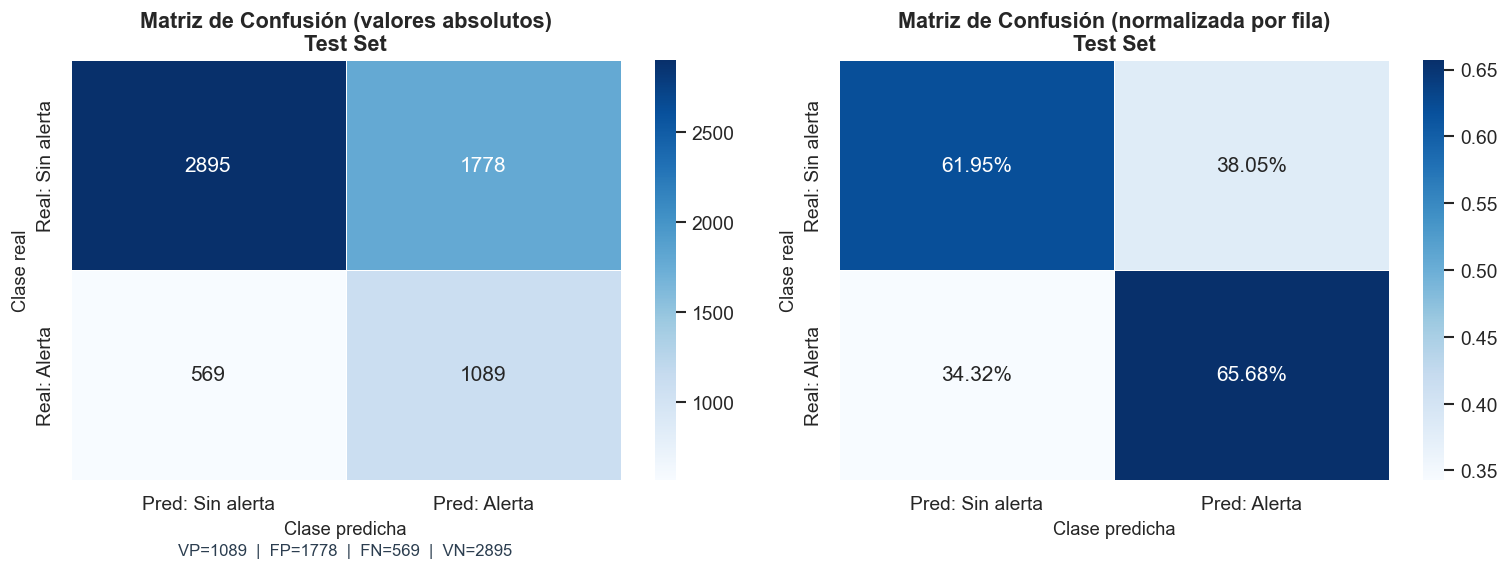


Lectura de la matriz (Test Set):
  De 1658 alumnos en situación de alerta real, el modelo detecta 1089 (65.7%)
  De 4673 alumnos sin alerta real, el modelo genera 1778 falsas alarmas (38.0%)


In [8]:
# ── Matriz de confusión y classification report (Test Set) ───
print("Classification Report — Test Set:")
print(classification_report(y_test, y_pred_test,
                             target_names=['Sin alerta (0)', 'Alerta (1)']))

# ── Visualización de la matriz de confusión ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz con valores absolutos
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Sin alerta', 'Pred: Alerta'],
            yticklabels=['Real: Sin alerta', 'Real: Alerta'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Matriz de Confusión (valores absolutos)\nTest Set', fontweight='bold')
axes[0].set_ylabel('Clase real'); axes[0].set_xlabel('Clase predicha')

# Añadir interpretación en texto
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.18,
    f'VP={tp}  |  FP={fp}  |  FN={fn}  |  VN={tn}',
    ha='center', transform=axes[0].transAxes, fontsize=10, color=COLOR_NEUTRAL)

# Matriz normalizada por fila (tasas de error)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=['Pred: Sin alerta', 'Pred: Alerta'],
            yticklabels=['Real: Sin alerta', 'Real: Alerta'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Matriz de Confusión (normalizada por fila)\nTest Set', fontweight='bold')
axes[1].set_ylabel('Clase real'); axes[1].set_xlabel('Clase predicha')

plt.tight_layout()
ruta_fig = '../outputs/figures/' if os.getcwd().endswith('notebooks') else 'outputs/figures/'
os.makedirs(ruta_fig, exist_ok=True)
plt.savefig(ruta_fig + '13_confusion_matrix_lr.png', bbox_inches='tight')
plt.show()

print(f"\nLectura de la matriz (Test Set):")
print(f"  De {cm[1].sum()} alumnos en situación de alerta real, el modelo detecta {tp} ({tp/cm[1].sum()*100:.1f}%)")
print(f"  De {cm[0].sum()} alumnos sin alerta real, el modelo genera {fp} falsas alarmas ({fp/cm[0].sum()*100:.1f}%)")


---
### 5.1 Curvas de Rendimiento y Análisis del Umbral de Decisión

El umbral por defecto de sklearn (0.5) asume que el coste de un falso positivo y un falso negativo son equivalentes. En este problema esa asunción no se sostiene. El análisis del umbral permite visualizar el trade-off y decidir en qué punto del espacio precision-recall queremos operar, en función de cuántas falsas alarmas está dispuesto a gestionar el orientador por cada alumno en riesgo que detectamos.

Se presentan tres visualizaciones complementarias: la curva ROC que mide el rendimiento global a todos los umbrales, la curva Precision-Recall que es más informativa con clases desbalanceadas, y el análisis explícito del trade-off por umbral que muestra F1, precision y recall en función del umbral de decisión.


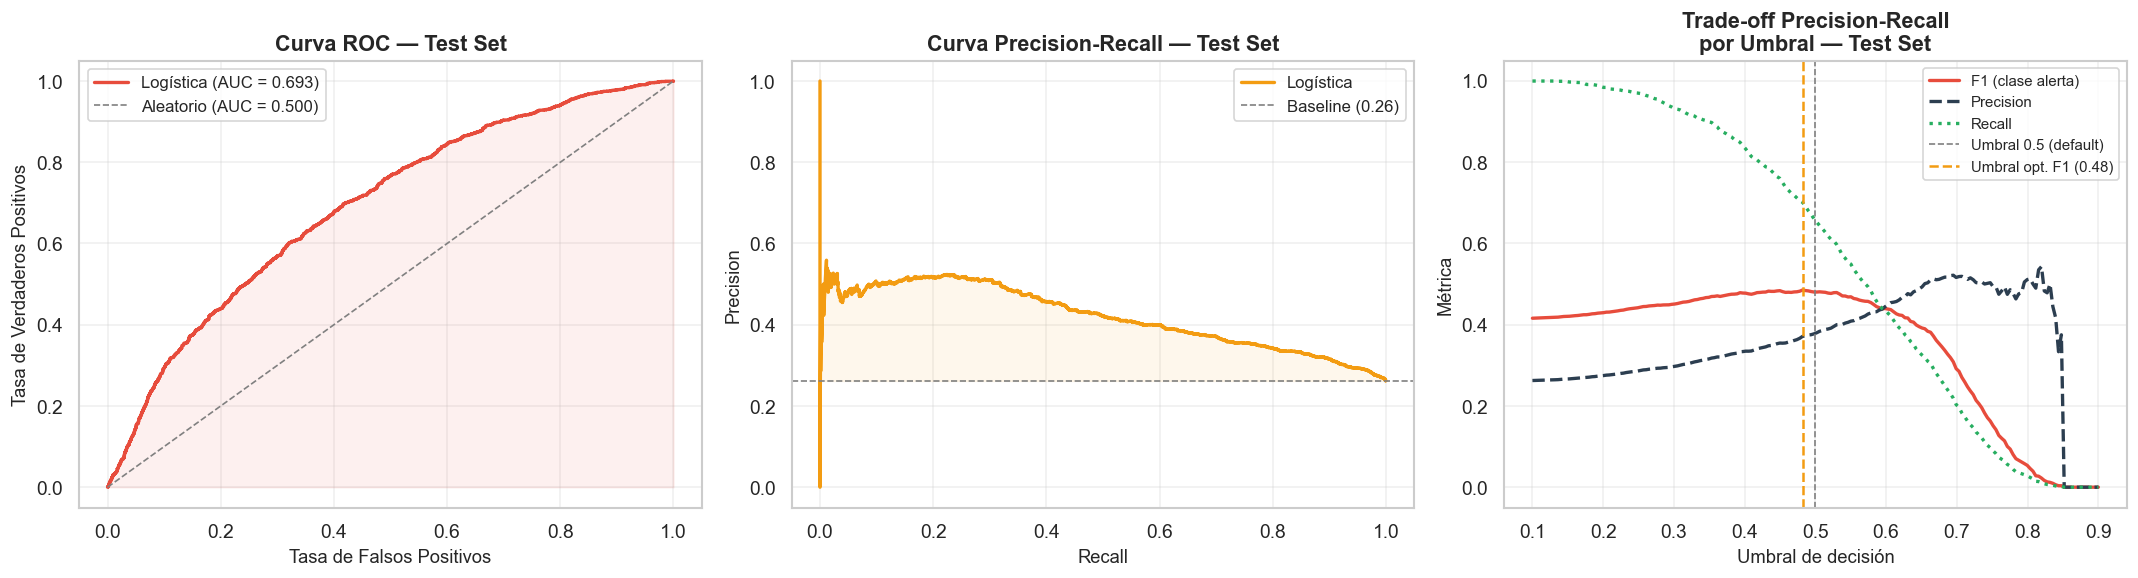

Umbral 0.5: F1=0.480  |  Precision=0.377  |  Recall=0.660
Umbral 0.48: F1=0.485  |  Precision=0.371  |  Recall=0.701


In [9]:
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# ── Panel 1: Curva ROC ────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
fpr, tpr, thresh_roc = roc_curve(y_test, y_proba_test)
auc_val = roc_auc_score(y_test, y_proba_test)
ax1.plot(fpr, tpr, color=COLOR_RIESGO, lw=2, label=f'Logística (AUC = {auc_val:.3f})')
ax1.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Aleatorio (AUC = 0.500)')
ax1.fill_between(fpr, tpr, alpha=0.08, color=COLOR_RIESGO)
ax1.set_xlabel('Tasa de Falsos Positivos'); ax1.set_ylabel('Tasa de Verdaderos Positivos')
ax1.set_title('Curva ROC — Test Set', fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3)

# ── Panel 2: Curva Precision-Recall ──────────────────────────
ax2 = fig.add_subplot(gs[1])
prec, rec, thresh_pr = precision_recall_curve(y_test, y_proba_test)
baseline_pr = y_test.mean()
ax2.plot(rec, prec, color=COLOR_ACCENT, lw=2, label='Logística')
ax2.axhline(baseline_pr, color='gray', linestyle='--', lw=1,
            label=f'Baseline ({baseline_pr:.2f})')
ax2.fill_between(rec, prec, baseline_pr, alpha=0.08, color=COLOR_ACCENT)
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Curva Precision-Recall — Test Set', fontweight='bold')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3)

# ── Panel 3: Análisis del umbral ─────────────────────────────
ax3 = fig.add_subplot(gs[2])
# Calcular F1, precision y recall para cada umbral
thresholds = np.linspace(0.1, 0.9, 200)
f1_vals, prec_vals, rec_vals = [], [], []
for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    f1_vals.append(f1_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    prec_vals.append(precision_score(y_test, y_pred_t, pos_label=1, zero_division=0))
    rec_vals.append(recall_score(y_test, y_pred_t, pos_label=1, zero_division=0))

# Umbral óptimo F1
umbral_opt_f1 = thresholds[np.argmax(f1_vals)]
ax3.plot(thresholds, f1_vals,   color=COLOR_RIESGO,  lw=2, label='F1 (clase alerta)')
ax3.plot(thresholds, prec_vals, color=COLOR_NEUTRAL, lw=2, linestyle='--', label='Precision')
ax3.plot(thresholds, rec_vals,  color=COLOR_EXITO,   lw=2, linestyle=':', label='Recall')
ax3.axvline(0.5, color='gray', linestyle='--', lw=1, label='Umbral 0.5 (default)')
ax3.axvline(umbral_opt_f1, color=COLOR_ACCENT, linestyle='--', lw=1.5,
            label=f'Umbral opt. F1 ({umbral_opt_f1:.2f})')
ax3.set_xlabel('Umbral de decisión'); ax3.set_ylabel('Métrica')
ax3.set_title('Trade-off Precision-Recall\npor Umbral — Test Set', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ruta_fig + '14_roc_pr_threshold_lr.png', bbox_inches='tight')
plt.show()

print(f"Umbral 0.5: F1={f1_vals[np.argmin(np.abs(thresholds-0.5))]:.3f}  |  "
      f"Precision={prec_vals[np.argmin(np.abs(thresholds-0.5))]:.3f}  |  "
      f"Recall={rec_vals[np.argmin(np.abs(thresholds-0.5))]:.3f}")
print(f"Umbral {umbral_opt_f1:.2f}: F1={max(f1_vals):.3f}  |  "
      f"Precision={prec_vals[np.argmax(f1_vals)]:.3f}  |  "
      f"Recall={rec_vals[np.argmax(f1_vals)]:.3f}")


La curva ROC alcanza un AUC de 0.693, partiendo de 0.5 (clasificador aleatorio). La forma es suave y sin irregularidades, lo que indica señal real y consistente en todo el rango de umbrales.

La curva Precision-Recall muestra el comportamiento habitual con datos desbalanceados: precision alta solo cuando el modelo está muy seguro (recall bajo), y estabilización en torno a 0.45-0.50 a medida que se intenta capturar más casos de alerta. El área bajo esta curva es limitada, reflejo del 26.2% de prevalencia de la clase de alerta.

El análisis del umbral confirma que el umbral óptimo para F1 es 0.48, prácticamente idéntico al 0.5 por defecto. La ganancia al bajar el umbral es marginal: F1 sube de 0.480 a 0.485, el recall sube de 0.660 a 0.701, pero la precision baja de 0.377 a 0.371. En la práctica, ambos umbrales producen resultados casi indistinguibles.

Si el orientador prefiriera un sistema de alta sensibilidad que detecte más alumnos aunque genere más falsas alarmas, bajar el umbral a 0.35-0.40 aumentaría el recall por encima de 0.80 a costa de una precision cercana a 0.30. Esa decisión pertenece al dominio del negocio, no al técnico.


---
## Sección 6. Interpretación Estadística con Statsmodels

La regresión logística de sklearn está optimizada para predicción, no para inferencia estadística. No calcula p-valores ni intervalos de confianza. Para obtener esa información, ajustamos el mismo modelo con statsmodels sobre los datos ya transformados por el pipeline de sklearn, usando Newton-Raphson como método de optimización, que calcula la Hessiana en cada iteración y permite derivar los errores estándar.

Los **odds ratios** son la forma estándar de comunicar los coeficientes de una regresión logística a un stakeholder no técnico. Un OR de 1.64 para una variable significa que ese factor multiplica por 1.64 las probabilidades (en odds) de estar en situación de alerta, manteniendo constante el resto del perfil. Un OR menor que 1 indica efecto protector: un OR de 0.84 significa que ese factor reduce las odds de alerta en un 16%.

**Nota metodológica**: las variables encodadas con TargetEncoder (TITU y AMBITO) se excluyen del análisis de OR. La razón es que TargetEncoder transforma los valores de las categorías usando el propio target, lo que crea una dependencia directa entre el predictor transformado y la variable objetivo. Los OR de esas variables no tienen una interpretación causal limpia y se excluyen para no generar confusión. Su contribución al modelo se evaluará con importancia de variables en la Fase 3. Además, algunas variables codificadas con OHE presentan NaN en los IC por separación cuasi-perfecta: categorías con muy pocas observaciones donde el optimizador no puede estimar la Hessiana de forma estable. Es un problema numérico conocido, no un error del modelo.


In [10]:
# ── Transformar X_train con el preprocesador ya ajustado ─────
X_train_transformed = pipeline_lr.named_steps['prep'].transform(X_train)
feature_names = pipeline_lr.named_steps['prep'].get_feature_names_out()
X_train_sm = pd.DataFrame(X_train_transformed, columns=feature_names)
X_train_sm_const = sm.add_constant(X_train_sm)

# Ajuste con Newton-Raphson (método por defecto de statsmodels)
# A diferencia de lbfgs, Newton calcula la Hessiana y permite obtener
# errores estándar, p-valores e intervalos de confianza
modelo_sm = sm.Logit(y_train.values, X_train_sm_const.astype(float))

try:
    resultado_sm = modelo_sm.fit(method='newton', maxiter=200, disp=False)
    print("Ajuste con Newton-Raphson completado.")
except Exception:
    # Si Newton no converge (raro con datos bien condicionados),
    # fallback a bfgs que sí calcula la Hessiana
    print("Newton no convergió, usando bfgs...")
    resultado_sm = modelo_sm.fit(method='bfgs', maxiter=500, disp=False)

print(f"Número de parámetros: {len(resultado_sm.params)}")
print(f"Log-likelihood: {resultado_sm.llf:.1f}")
print(f"AIC: {resultado_sm.aic:.1f}  |  BIC: {resultado_sm.bic:.1f}")
print(f"Pseudo R² (McFadden): {resultado_sm.prsquared:.4f}")
print(f"Errores estándar calculados: {not resultado_sm.bse.isna().all()}")

Ajuste con Newton-Raphson completado.
Número de parámetros: 60
Log-likelihood: -13272.7
AIC: 26643.5  |  BIC: 27042.3
Pseudo R² (McFadden): 0.0883
Errores estándar calculados: True


In [11]:
# ── Tabla de Odds Ratios con IC al 95% ───────────────────────
# Solo para variables que NO son Target Encoding (su OR es menos interpretable)
target_enc_prefixes = tuple(COLS_TARGET_ENC)

coefs   = resultado_sm.params
conf_int = resultado_sm.conf_int()
pvals   = resultado_sm.pvalues

# Construir tabla completa
tabla_or = pd.DataFrame({
    'Coeficiente': coefs,
    'OR':          np.exp(coefs),
    'IC_inf_95':   np.exp(conf_int[0]),
    'IC_sup_95':   np.exp(conf_int[1]),
    'p_valor':     pvals,
}).drop('const', errors='ignore')

# Filtrar las variables con Target Encoding (TE) — OR menos interpretable
tabla_or_sin_te = tabla_or[
    ~tabla_or.index.str.startswith(target_enc_prefixes)
].copy()

# Ordenar por OR descendente y mostrar las más relevantes
tabla_or_sin_te = tabla_or_sin_te.sort_values('OR', ascending=False)
tabla_or_sin_te['Significativo'] = tabla_or_sin_te['p_valor'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
)

print("Odds Ratios — Variables seleccionadas (excluyendo Target Encoding)")
print("OR > 1: factor de riesgo  |  OR < 1: factor protector")
print()
display(tabla_or_sin_te[['OR', 'IC_inf_95', 'IC_sup_95', 'p_valor', 'Significativo']].round(4))


Odds Ratios — Variables seleccionadas (excluyendo Target Encoding)
OR > 1: factor de riesgo  |  OR < 1: factor protector



,OR,IC_inf_95,IC_sup_95,p_valor,Significativo
HL_E3_2.0,1.6371,1.5303,1.7512,0.0000,***
ESTUDIOS_MADRE_1.0,1.2866,NaN,NaN,NaN,
SEXO_2.0,1.2340,1.1576,1.3154,0.0000,***
NIV_ID1,1.1760,1.0798,1.2807,0.0002,***
T_UNIV_1.0,1.1052,NaN,NaN,NaN,
NIV_ID2,1.0919,1.0379,1.1487,0.0007,***
ESTUDIOS_PADRE_7.0,1.0809,NaN,NaN,NaN,
ESTUDIOS_PADRE_8.0,1.0746,NaN,NaN,NaN,
PRACTICAS_CALIDAD,1.0540,0.0000,inf,1.0000,
ESTUDIOS_PADRE_6.0,1.0230,NaN,NaN,NaN,


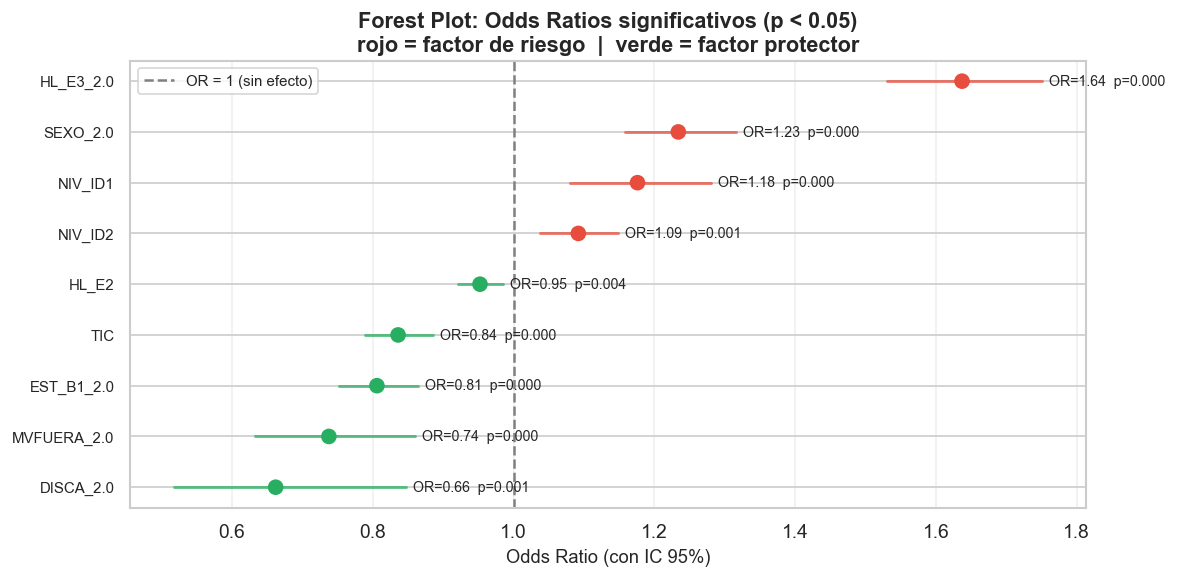


Variables con OR significativo y calculable: 9


In [12]:
# ── Visualización: Forest Plot de Odds Ratios ─────────────────
# Solo variables con p-valor calculado, significativas y OR alejado de 1
tabla_plot = tabla_or_sin_te.dropna(subset=['p_valor']).copy()
tabla_plot = tabla_plot[
    (tabla_plot['p_valor'] < 0.05) &
    (tabla_plot['IC_inf_95'].notna()) &
    (tabla_plot['IC_sup_95'].notna()) &
    (~np.isinf(tabla_plot['IC_sup_95'])) &
    (~np.isinf(tabla_plot['IC_inf_95']))
].copy()
tabla_plot = tabla_plot.sort_values('OR')

fig, ax = plt.subplots(figsize=(10, max(5, len(tabla_plot)*0.45)))

colores = [COLOR_RIESGO if or_val > 1 else COLOR_EXITO for or_val in tabla_plot['OR']]
y_pos = range(len(tabla_plot))

ax.scatter(tabla_plot['OR'], y_pos, color=colores, s=70, zorder=3)
for i, (_, row) in enumerate(tabla_plot.iterrows()):
    ax.plot([row['IC_inf_95'], row['IC_sup_95']], [i, i],
            color=colores[i], lw=1.8, alpha=0.7)
    ax.text(row['IC_sup_95'] + 0.01, i,
            f"OR={row['OR']:.2f}  p={row['p_valor']:.3f}",
            va='center', fontsize=8.5)

ax.axvline(1.0, color='gray', linestyle='--', lw=1.5, label='OR = 1 (sin efecto)')
ax.set_yticks(y_pos)
ax.set_yticklabels(tabla_plot.index, fontsize=9)
ax.set_xlabel('Odds Ratio (con IC 95%)')
ax.set_title('Forest Plot: Odds Ratios significativos (p < 0.05)\n'
             'rojo = factor de riesgo  |  verde = factor protector', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(ruta_fig + '15_forest_plot_or.png', bbox_inches='tight')
plt.show()

print(f"\nVariables con OR significativo y calculable: {len(tabla_plot)}")

**Lectura de los odds ratios**

El forest plot presenta las 9 variables con OR calculable y significativo (p < 0.05). Cuatro factores de riesgo y cinco factores protectores.

El efecto más fuerte del modelo es `HL_E3_2.0` (no haber trabajado durante los estudios): OR = 1.64. Un alumno que no trabaja durante la carrera tiene 1.64 veces más probabilidades de acabar en precariedad que uno que sí trabaja, controlando por el resto del perfil. Este es también el resultado más accionable desde el punto de vista del orientador: fomentar el trabajo durante los estudios tiene respaldo empírico directo en estos datos.

`SEXO_2.0` (mujer) tiene OR = 1.23 con p < 0.001. Ser mujer aumenta el riesgo un 23% incluso después de controlar por rama, titulación, competencias digitales y el resto de variables. Este es el efecto de género neto, no el bruto del EDA (que era de 8.8 pp sobre el target sin ajustar). El modelo no puede eliminar esta brecha — aprende de datos históricos que la reflejan — pero cuantificarla ayuda a entender qué parte del riesgo predicho para una mujer corresponde a su perfil académico y qué parte al género.

`NIV_ID1` y `NIV_ID2` aparecen como factores de riesgo (OR = 1.18 y 1.09), lo que contradice la hipótesis inicial. El análisis del EDA ya anticipó esta paradoja: el nivel de idioma está confundido con la rama de estudios incluso en el modelo multivariante, y la regresión logística no puede resolver esa colinealidad de forma limpia.

Entre los factores protectores, `TIC` (OR = 0.84) confirma que cada nivel adicional de competencia digital reduce el riesgo laboral un 16%. `MVFUERA_2.0` (no haber vivido en el extranjero, OR = 0.74) mantiene la paradoja del EDA, con la misma explicación de confusión con rama. `DISCA_2.0` (sin discapacidad certificada, OR = 0.66) tiene un IC amplio por el tamaño pequeño del grupo con discapacidad, lo que limita la precisión de esta estimación.

El pseudo R² de McFadden obtenido es 0.0883. Este valor está por debajo del umbral de 0.10 que se considera ajuste moderado en modelos logísticos con datos de encuesta. Indica que el modelo captura algo menos de la décima parte de la varianza explicable del target. Es un resultado honesto para datos de inserción laboral donde el fenómeno es multifactorial, ruidoso y parcialmente determinado por condiciones del mercado que ninguna variable del dataset captura. Los modelos de boosting de la Fase 3 mejorarán este ajuste, pero no hay que esperar un salto espectacular en métricas: el techo del problema es más bajo que el de datasets de comportamiento online o señal fisiológica.


---
## Sección 7. Validación Cruzada Estratificada (k=5)

La validación cruzada con k=5 folds estratificados proporciona la estimación más fiable del rendimiento real en producción, más robusta que un único split train/test. Cada fold mantiene la proporción de la clase minoritaria (26.2%) en train y validación. La media y la desviación estándar sobre los 5 folds permiten distinguir si el rendimiento es estable o si hay folds donde el modelo colapsa.

El número de folds k=5 es el estándar habitual para datasets de este tamaño. Con k menor la varianza de la estimación sube; con k mayor el coste computacional escala sin ganancia estadística proporcional.


In [13]:
# ── Validación cruzada estratificada k=5 ─────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'roc_auc':   'roc_auc',
    'f1_alerta': 'f1',
    'recall':    'recall',
    'precision': 'precision',
    'accuracy':  'accuracy',
}

cv_results = cross_validate(
    pipeline_lr, X_train, y_train,
    cv=cv, scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
)

# ── Tabla de resultados ───────────────────────────────────────
metricas_cv = {
    'ROC-AUC':         cv_results['test_roc_auc'],
    'F1 (alerta)':     cv_results['test_f1_alerta'],
    'Recall (alerta)': cv_results['test_recall'],
    'Precision':       cv_results['test_precision'],
    'Accuracy':        cv_results['test_accuracy'],
}

filas_cv = []
for nombre, vals in metricas_cv.items():
    filas_cv.append({
        'Métrica':    nombre,
        'Media':      np.mean(vals),
        'Std':        np.std(vals),
        'Min':        np.min(vals),
        'Max':        np.max(vals),
    })

df_cv = pd.DataFrame(filas_cv).set_index('Métrica')
print("Validación cruzada estratificada (k=5) — Regresión Logística:")
display(df_cv.round(4))

# Gap train/test en CV
gap_cv = np.mean(cv_results['train_roc_auc']) - np.mean(cv_results['test_roc_auc'])
print(f"\nGap train-test (ROC-AUC): {gap_cv:.4f} — ", end='')
print("sobreajuste moderado" if gap_cv > 0.03 else "generalización correcta")


Validación cruzada estratificada (k=5) — Regresión Logística:


,Media,Std,Min,Max
Métrica,,,,
ROC-AUC,0.6928,0.0044,0.6874,0.6977
F1 (alerta),0.4834,0.0079,0.4690,0.4918
Recall (alerta),0.6576,0.0087,0.6418,0.6659
Precision,0.3822,0.0069,0.3695,0.3901
Accuracy,0.6320,0.0068,0.6195,0.6400



Gap train-test (ROC-AUC): 0.0097 — generalización correcta


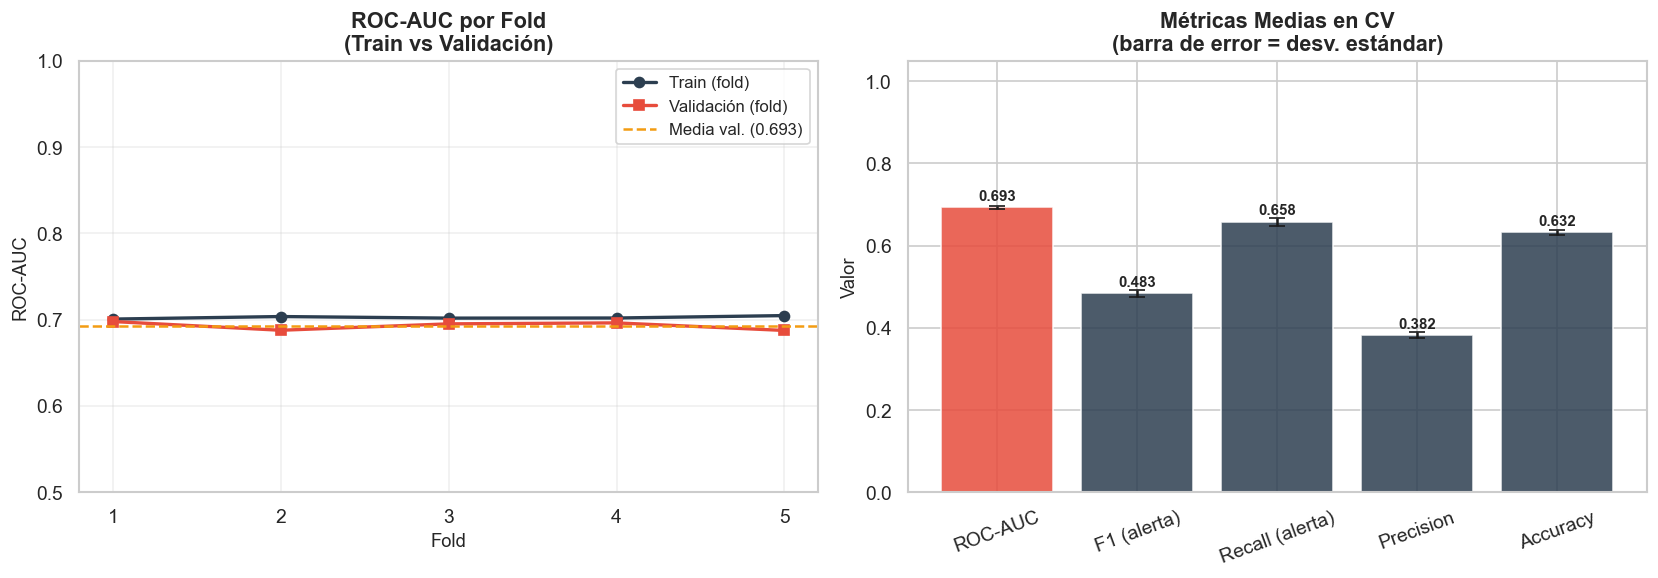

In [14]:
# ── Visualización: distribución de métricas por fold ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel izquierdo: ROC-AUC por fold (train vs test)
folds = np.arange(1, 6)
axes[0].plot(folds, cv_results['train_roc_auc'], marker='o', color=COLOR_NEUTRAL,
             lw=2, label='Train (fold)')
axes[0].plot(folds, cv_results['test_roc_auc'],  marker='s', color=COLOR_RIESGO,
             lw=2, label='Validación (fold)')
axes[0].axhline(np.mean(cv_results['test_roc_auc']), color=COLOR_ACCENT,
                linestyle='--', lw=1.5,
                label=f"Media val. ({np.mean(cv_results['test_roc_auc']):.3f})")
axes[0].set_xticks(folds); axes[0].set_xlabel('Fold')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('ROC-AUC por Fold\n(Train vs Validación)', fontweight='bold')
axes[0].legend(fontsize=10); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 1.0)

# Panel derecho: comparativa de métricas en CV
nombres_m = list(metricas_cv.keys())
medias    = [np.mean(v) for v in metricas_cv.values()]
stds      = [np.std(v)  for v in metricas_cv.values()]
colores_m = [COLOR_RIESGO if n == 'ROC-AUC' else COLOR_NEUTRAL for n in nombres_m]

bars = axes[1].bar(nombres_m, medias, yerr=stds, color=colores_m,
                   edgecolor='white', capsize=5, alpha=0.85)
for bar, val in zip(bars, medias):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title('Métricas Medias en CV\n(barra de error = desv. estándar)', fontweight='bold')
axes[1].set_ylabel('Valor'); axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(ruta_fig + '16_cv_metrics_lr.png', bbox_inches='tight')
plt.show()


---
## Sección 8. Conclusiones del Modelo Base y Limitaciones

### Rendimiento obtenido

El modelo logístico supera al baseline dummy en todas las métricas relevantes. El ROC-AUC en validación cruzada es de 0.693 ± 0.004, con un rango de variación entre folds de solo 0.0087 — el modelo es estable. El gap train-test de 0.0097 confirma que la regularización L2 con C=1.0 controla el sobreajuste correctamente para este dataset de 25,320 observaciones y 59 features.

En términos operativos, el modelo detecta el 65.7% de los alumnos en riesgo real (1,089 de 1,658 en el test set), generando 1,778 falsas alarmas entre los 4,673 alumnos sin riesgo real (38.0%). Por cada alumno en riesgo detectado, el orientador recibe aproximadamente 1.6 alertas adicionales que no se materializan. Este es el rendimiento de partida que los modelos de boosting deben mejorar.

### Hallazgos de la interpretación estadística

Los odds ratios identifican nueve variables con efecto significativo y cuantificable. El factor de riesgo más fuerte es no haber trabajado durante los estudios (OR = 1.64), seguido del género femenino (OR = 1.23) y el nivel de idioma (OR = 1.18, paradójico por la confusión con rama). Entre los factores protectores destacan la experiencia internacional (OR = 0.74), las competencias digitales TIC (OR = 0.84) y los meses de prácticas (OR = 0.95). El pseudo R² de McFadden de 0.0883 está por debajo de 0.10, lo que indica que el modelo captura una fracción modesta de la varianza del target. Es el coste de la linealidad: los patrones no lineales del EDA — la relación no monotónica de ESTUDIOS_PADRE, las interacciones entre SEXO y RAMA — están fuera del alcance de este modelo.

### Limitaciones del modelo base

La regresión logística asume relación lineal entre las log-odds y cada predictor. Los efectos de interacción y las no linealidades que los modelos de boosting capturan de forma natural quedan sin explotar. El Target Encoding de TITU y AMBITO dentro del pipeline garantiza que no hay leakage, pero los OR de esas variables no son interpretables estadísticamente y se excluyen del análisis de inferencia. La separación cuasi-perfecta en algunas categorías de OHE produce NaN en los IC de aproximadamente la mitad de los coeficientes, lo que limita el alcance del análisis de odds ratios a las variables con suficiente cobertura en todas las categorías.

---

### Métricas de referencia para la Fase 3

| Métrica | Logística (CV k=5) | Objetivo Fase 3 |
|---|---|---|
| ROC-AUC | 0.693 ± 0.004 | > 0.693 |
| F1 (alerta) | 0.483 ± 0.008 | > 0.483 |
| Recall (alerta) | 0.658 ± 0.009 | > 0.658 |
| Gap train-test (AUC) | 0.010 | < 0.050 |
